# Librerias

In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import os
import shutil
import random

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix

## División del dataset

El dataset original se divide automáticamente en conjuntos de entrenamiento y validación utilizando la librería `splitfolders`.  

Se emplea una proporción de 80% para entrenamiento y 20% para validación, asegurando una distribución reproducible mediante una semilla aleatoria (`seed=42`). Esto permite evaluar el desempeño del modelo con datos no vistos durante el entrenamiento.

In [13]:
splitfolders.ratio(
    "data_original",
    output="data",
    seed=42,
    ratio=(0.8, 0.2)
)

Copying files: 7276 files [00:20, 363.38 files/s] 


## Reorganización de clases

Con el objetivo de simplificar el problema de clasificación y reducir la similitud entre categorías relacionadas con el uso del teléfono, se realizó una reorganización del dataset.  

Las clases **`talking_phone`** y **`texting_phone`** fueron fusionadas en una nueva categoría denominada **`using_phone`**. De esta manera, el modelo trabajará con las siguientes cuatro clases finales:

- `safe_driving`
- `turning`
- `others`
- `using_phone`

Además, se crearon automáticamente las carpetas correspondientes para los conjuntos de entrenamiento y validación, copiando las imágenes hacia la nueva estructura del dataset.

In [14]:
source = "data"
dest = "data_merged_phone"

for split in ["train", "val"]:

    # Crear carpetas destino
    for cls in ["safe_driving", "turning", "others", "using_phone"]:
        os.makedirs(
            os.path.join(dest, split, cls),
            exist_ok=True
        )

    # Copiar safe_driving
    src = os.path.join(source, split, "safe_driving")
    dst = os.path.join(dest, split, "safe_driving")

    for img in os.listdir(src):
        shutil.copy(
            os.path.join(src, img),
            os.path.join(dst, img)
        )

    # Copiar turning
    src = os.path.join(source, split, "turning")
    dst = os.path.join(dest, split, "turning")

    for img in os.listdir(src):
        shutil.copy(
            os.path.join(src, img),
            os.path.join(dst, img)
        )

    # Copiar others
    src = os.path.join(source, split, "others")
    dst = os.path.join(dest, split, "others")

    for img in os.listdir(src):
        shutil.copy(
            os.path.join(src, img),
            os.path.join(dst, img)
        )

    # Unir talking_phone + texting_phone → using_phone
    for old_class in ["talking_phone", "texting_phone"]:

        src = os.path.join(source, split, old_class)
        dst = os.path.join(dest, split, "using_phone")

        for img in os.listdir(src):
            shutil.copy(
                os.path.join(src, img),
                os.path.join(dst, img)
            )

print("Nuevo dataset creado correctamente.")

Nuevo dataset creado correctamente.


## Configuración inicial

En esta sección se definen los parámetros principales utilizados durante el entrenamiento del modelo:

- **Dataset:** ruta del conjunto de datos reorganizado.  
- **Batch Size:** cantidad de imágenes procesadas por iteración.  
- **Image Size:** tamaño al que se redimensionan las imágenes para ingresar al modelo.  
- **Epochs:** número de ciclos completos de entrenamiento.  

Además, se detecta automáticamente si existe disponibilidad de GPU mediante CUDA, permitiendo acelerar el proceso de entrenamiento utilizando hardware especializado.

In [4]:
DATASET_PATH = "data_merged_phone"
BATCH_SIZE = 64
IMG_SIZE = 224
EPOCHS = 25

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cuda
NVIDIA GeForce RTX 5060


## Transformaciones y aumento de datos

Para mejorar la capacidad de generalización del modelo y reducir el riesgo de *overfitting*, se aplicaron diferentes técnicas de aumento de datos (*Data Augmentation*) sobre las imágenes de entrenamiento.  

Entre las transformaciones utilizadas se incluyen:

- Redimensionamiento de imágenes a `224x224` píxeles.  
- Volteo horizontal aleatorio.  
- Rotaciones aleatorias.  
- Recortes y reescalados aleatorios.  
- Variaciones de brillo, contraste y saturación.  
- Transformaciones de perspectiva.  

Finalmente, las imágenes son convertidas a tensores y normalizadas utilizando los valores estándar de ImageNet, ya que el modelo base preentrenado fue entrenado originalmente sobre dicho dataset.

In [5]:
train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.25
    ),

    transforms.RandomPerspective(
        distortion_scale=0.2,
        p=0.3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Transformaciones para validación

Para el conjunto de validación se aplican únicamente transformaciones básicas de preprocesamiento, sin aumento de datos.  

Las imágenes son redimensionadas al tamaño requerido por el modelo, convertidas a tensores y posteriormente normalizadas utilizando los parámetros estándar de ImageNet. Esto permite evaluar el rendimiento del modelo sobre datos más cercanos a escenarios reales.

In [6]:
val_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


## Carga del dataset

Las imágenes de entrenamiento y validación se cargan utilizando `ImageFolder`, lo que permite organizar automáticamente las clases según la estructura de carpetas del dataset.  

Posteriormente, se crean los `DataLoader`, encargados de procesar las imágenes en lotes (*batches*) para optimizar el entrenamiento del modelo.  

- En entrenamiento se habilita `shuffle=True` para mezclar las imágenes y mejorar el aprendizaje.  
- En validación se mantiene el orden original de los datos.  

Además, se utilizan múltiples procesos (`num_workers`) y memoria anclada (`pin_memory`) para acelerar la carga de datos durante el entrenamiento en GPU.

In [7]:
train_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/val",
    transform=val_transform
)

print("Clases:", train_dataset.classes)
print("Train imágenes:", len(train_dataset))
print("Val imágenes:", len(val_dataset))


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


Clases: ['others', 'safe_driving', 'turning', 'using_phone']
Train imágenes: 5819
Val imágenes: 1457


## Construcción del modelo con Transfer Learning

Para este proyecto se utilizó la arquitectura **ResNet18** preentrenada sobre el dataset ImageNet, aplicando la técnica de *Transfer Learning*.  

In [8]:
model = models.resnet18(weights="DEFAULT")

for param in model.parameters():
    param.requires_grad = False


num_features = model.fc.in_features

model.fc = torch.nn.Linear(
    num_features,
    len(train_dataset.classes)
)

model = model.to(device)

## Función de pérdida y optimizador

Se utilizó la función de pérdida **CrossEntropyLoss**, adecuada para problemas de clasificación multiclase. Esta función permite medir la diferencia entre las predicciones del modelo y las etiquetas reales.  

Como optimizador se empleó **Adam**, ajustando únicamente los parámetros de la última capa de clasificación añadida durante el proceso de *Transfer Learning*. Además, se estableció una tasa de aprendizaje (`learning rate`) de `0.001`.

In [9]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)


## Entrenamiento y validación del modelo

El modelo fue entrenado durante varias épocas utilizando los datos del conjunto de entrenamiento. En cada iteración se realizó el cálculo de la pérdida, la propagación hacia atrás (*backpropagation*) y la actualización de los pesos mediante el optimizador Adam.  

Posteriormente, al finalizar cada época, el modelo fue evaluado utilizando el conjunto de validación para medir su capacidad de generalización sobre datos no vistos.  

Durante el entrenamiento se almacenaron métricas como:

- **Training Loss:** error promedio en entrenamiento.  
- **Validation Accuracy:** precisión obtenida sobre el conjunto de validación.  

Además, se implementó un mecanismo para guardar automáticamente el modelo con mejor desempeño en validación, conservando así la versión más óptima obtenida durante el entrenamiento.

In [15]:
train_loss_history = []
val_acc_history = []

best_val_acc = 0


for epoch in range(EPOCHS):

    # ENTRAMIENTO
    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_loss)


    # VALIDACIÓN
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = correct / total
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Guardar mejor modelo
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": train_dataset.classes
        }, "best_driver_behavior_model.pth")

        print(">>> Mejor modelo guardado <<<")

Epoch 1/25 | Loss: 0.7088 | Val Acc: 0.7255
>>> Mejor modelo guardado <<<
Epoch 2/25 | Loss: 0.7017 | Val Acc: 0.7179
Epoch 3/25 | Loss: 0.6988 | Val Acc: 0.7111
Epoch 4/25 | Loss: 0.7032 | Val Acc: 0.7035
Epoch 5/25 | Loss: 0.7003 | Val Acc: 0.7220
Epoch 6/25 | Loss: 0.7025 | Val Acc: 0.7021
Epoch 7/25 | Loss: 0.7100 | Val Acc: 0.7069
Epoch 8/25 | Loss: 0.7008 | Val Acc: 0.7316
>>> Mejor modelo guardado <<<
Epoch 9/25 | Loss: 0.6974 | Val Acc: 0.7207
Epoch 10/25 | Loss: 0.6936 | Val Acc: 0.7261
Epoch 11/25 | Loss: 0.6944 | Val Acc: 0.6960
Epoch 12/25 | Loss: 0.6903 | Val Acc: 0.7268
Epoch 13/25 | Loss: 0.6947 | Val Acc: 0.7227
Epoch 14/25 | Loss: 0.6845 | Val Acc: 0.7323
>>> Mejor modelo guardado <<<
Epoch 15/25 | Loss: 0.6905 | Val Acc: 0.7337
>>> Mejor modelo guardado <<<
Epoch 16/25 | Loss: 0.6975 | Val Acc: 0.7316
Epoch 17/25 | Loss: 0.6952 | Val Acc: 0.7165
Epoch 18/25 | Loss: 0.6860 | Val Acc: 0.7296
Epoch 19/25 | Loss: 0.6894 | Val Acc: 0.7227
Epoch 20/25 | Loss: 0.6819 | Val A

## Visualización de la pérdida de entrenamiento

Para analizar el comportamiento del modelo durante el proceso de aprendizaje, se graficó la evolución de la función de pérdida (*Training Loss*) a lo largo de las épocas.  

Esta visualización permite identificar si el modelo está aprendiendo correctamente y verificar la estabilidad del entrenamiento conforme avanzan las iteraciones.

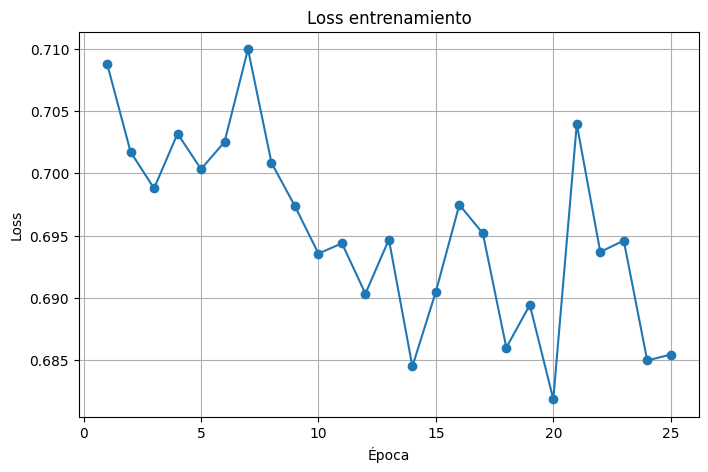

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, EPOCHS+1),
    train_loss_history,
    marker='o'
)

plt.title("Loss entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


## Evaluación del modelo

Una vez finalizado el entrenamiento, el modelo fue evaluado utilizando el conjunto de validación para medir su desempeño en la clasificación de comportamientos de conducción.  

Se generó un **reporte de clasificación** con métricas como precisión (*precision*), sensibilidad (*recall*) y *F1-score* para cada clase.  

Además, se almacenaron y visualizaron algunos ejemplos de imágenes mal clasificadas, permitiendo analizar posibles errores del modelo y comportamientos difíciles de distinguir.  

Finalmente, se construyó una **matriz de confusión**, útil para observar cómo el modelo distribuye sus predicciones entre las diferentes categorías y detectar confusiones frecuentes entre clases similares.

              precision    recall  f1-score   support

      others       0.58      0.45      0.51       237
safe_driving       0.80      0.63      0.70       336
     turning       0.78      0.83      0.81       268
 using_phone       0.72      0.85      0.78       616

    accuracy                           0.73      1457
   macro avg       0.72      0.69      0.70      1457
weighted avg       0.73      0.73      0.72      1457



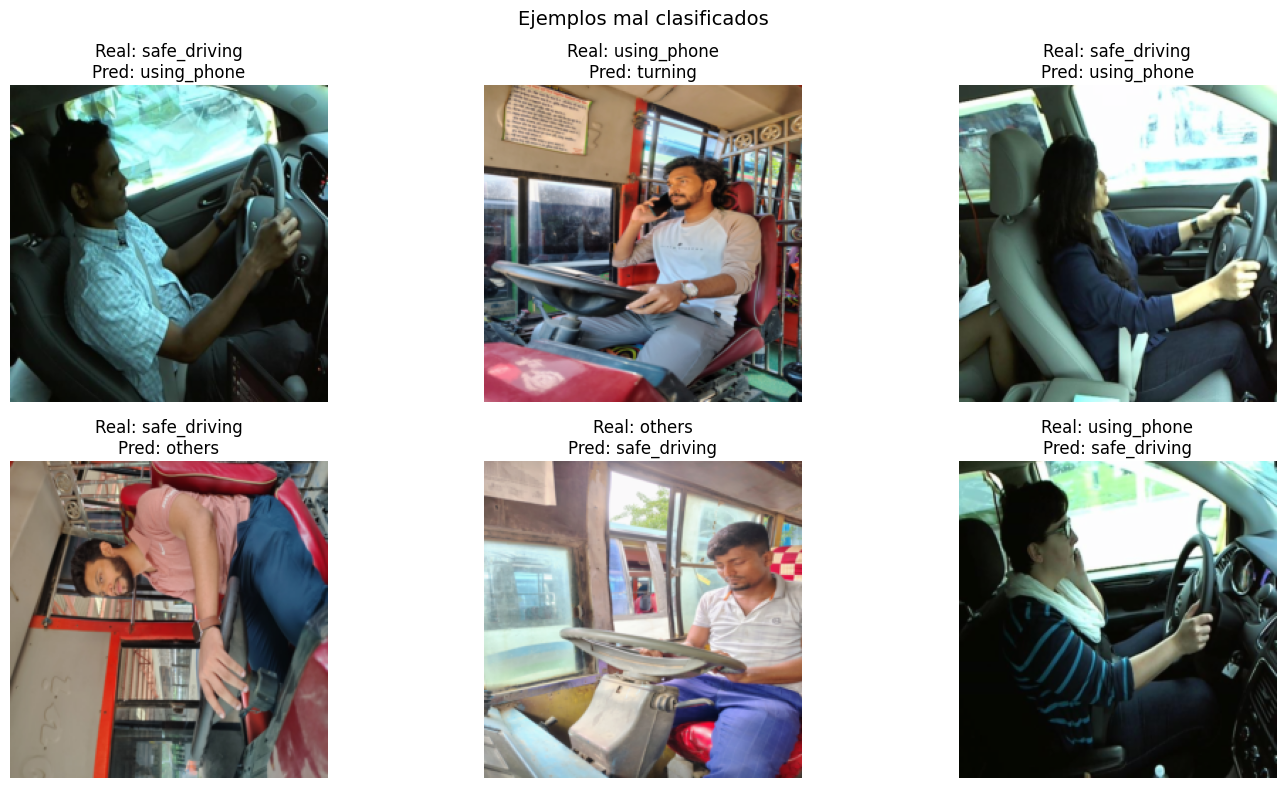

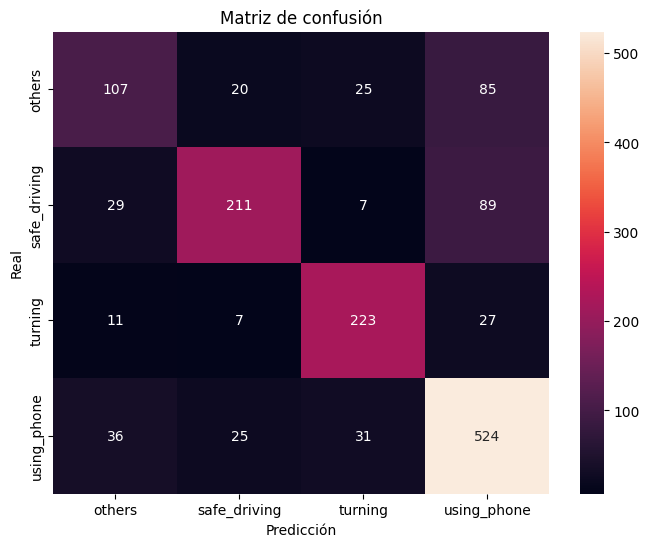

In [17]:
model.eval()

y_true = []
y_pred = []

# Lista para almacenar imágenes mal clasificadas
misclassified = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        # Guardar métricas
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Guardar imágenes mal clasificadas
        for i in range(len(labels)):

            if preds[i] != labels[i]:

                misclassified.append(
                    (
                        images[i].cpu(),
                        labels[i].cpu().item(),
                        preds[i].cpu().item()
                    )
                )

# REPORTE DE CLASIFICACIÓN
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

# MOSTRAR 6 ERRORES
if len(misclassified) > 0:

    samples = random.sample(
        misclassified,
        min(6, len(misclassified))
    )

    plt.figure(figsize=(15, 8))

    for idx, (img, true_label, pred_label) in enumerate(samples):

        # Convertir tensor a imagen
        img = img.permute(1, 2, 0).numpy()

        # Desnormalizar
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(2, 3, idx + 1)
        plt.imshow(img)

        plt.title(
            f"Real: {train_dataset.classes[true_label]}\n"
            f"Pred: {train_dataset.classes[pred_label]}"
        )

        plt.axis("off")

    plt.suptitle(
        "Ejemplos mal clasificados",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

else:
    print("No hubo errores.")


# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()